In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import os
import re
import json
import numpy as np

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


matplotlib 识别的字体名: Songti SC


In [172]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))


In [173]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [174]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())



In [175]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:
def train(X_train, y_train, X_val, y_val, key):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 200, step=10),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'random_state': 42,
            # 'use_label_encoder': False,
            'eval_metric': ['auc', 'logloss']
            # 'scale_pos_weight':
        }


        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)],  # 加入验证集
            verbose=False,
        )
        evals_result = model.evals_result()

        train_logloss = evals_result['validation_0']['logloss']
        val_logloss = evals_result['validation_1']['logloss']

        train_auc = evals_result['validation_0']['auc']
        val_auc = evals_result['validation_1']['auc']
        
        context = ""

        for key1, item1 in params.items():
            if key1 == 'use_label_encoder' or key1 == 'eval_metric':
                context = f"{context}{key1}:{item1}\n"
            else:
                # print(item1)
                context = f"{context}{key1}:{item1:.3f}\n"

        best_auc = 0
        for i in range(len(val_auc)):
            if val_auc[i] > best_auc:
                best_auc = val_auc[i]
                params['n_estimators'] = i

        return 1.0 - best_auc

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = best_trial.params
    best_params['random_state'] = 42

    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X_train, y_train)

    return [final_model,best_trial.params,best_params]

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name, key):
    # y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]

    # 最佳阈值
    best_thresh, best_f1 = 0.5, 0
    for thresh in np.arange(0.01, 0.99, 0.01):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = f1_score(y, pred_val)
        if f1 > best_f1:
            best_thresh, best_f1 = thresh, f1

    print(f"最佳阈值: {best_thresh:.2f}，测试集最大f1: {best_f1:.4f}")
    
     
    y_pred = (y_pred_proba >= best_thresh).astype(int)

    # if dataset_name == '测试':
    #     predict = [[], []]
    #     y = list(y)
    #     for i in range(len(y)):
    #         if y[i] == 0:
    #             predict[0].append(y_pred_proba[i])
    #         if y[i] == 1:
    #             predict[1].append(y_pred_proba[i])

    #     plt.boxplot(predict)
    #     plt.xticks([1, 2], ['非阴性组', '阴性组'])
    #     plt.title(key)
    #     plt.ylabel("可能性")
    #     plt.show()
    
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)
    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")
    
    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }

# 评估训练集、验证集和测试集
# train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
# val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
# test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

    # 可选：保存最佳模型
    # import joblib
    # joblib.dump(final_model, 'best_xgb_model.pkl')
    # print("\n最佳模型已保存为 'best_xgb_model.pkl'")

    # 可选：绘制特征重要性
    # import matplotlib.pyplot as plt

    # plt.figure(figsize=(10, 8))
    # xgb.plot_importance(final_model, max_num_features=15)
    # plt.title('Feature Importance')
    # plt.tight_layout()
    # plt.show()

In [ ]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/XGBoost/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)

    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - XGBoost ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/XGBoost/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}

    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/XGboost_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'XGboost_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'XGboost_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'XGboost_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'XGboost_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'XGboost_Dataset{current_dataset}'][model] = data_to_append
    print(existing_data)
    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)




In [ ]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):

    task_trans = {
        "阴性组vs其他": "NG vs Others",
        "感染性脑膜炎vs非感染性脑膜炎": "Infectious Meningitis vs Non-Infectious ",
        "细菌性脑膜炎vs其他感染性脑膜炎": "ABM vs Other Infectious Meningitis",
        "病毒性脑膜炎vs其他感染性脑膜炎": "VM vs Other Infectious Meningitis",
        "结核性脑膜炎vs其他感染性脑膜炎": "TBM vs Other Infectious Meningitis",
        "真菌性脑膜炎vs其他感染性脑膜炎": "FM vs Other Infectious Meningitis",
        "肿瘤性脑膜炎vs其他": "LMD vs Others",
        "自身免疫性脑膜炎vs其他": "AM vs Others",
        "病毒性脑膜炎vs病毒性脑炎": "VM vs VE"
    }
    
    # ---------------- SHAP 分析 -----------------
    explainer = shap.TreeExplainer(final_model, X_train)
    shap_values = explainer.shap_values(X_test)
    shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values
    trans_df = pd.read_excel('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/ipynb/项目英文缩写与全称.xlsx')
    trans_dict = {}
      
    for index, row in trans_df.iterrows():
        trans_dict[row['中文项目名称']] = row['英文缩写']
    # new_index = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for x in list(X_test.columns)]
    X_test = X_test.rename(columns={'血_葡萄糖空腹_定量': '血_葡萄糖[空腹]_定量'})
    X_test = X_test.rename(columns={'血_肌酸激酶.MB型质量法_定量': '血_肌酸激酶.MB型[质量法]_定量'})   
    X_test.columns = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for i, x in enumerate(X_test.columns)]
     
    X_test_en = X_test.rename(columns=trans_dict)
    feature_names_en = list(X_test_en.columns)

    # print(shap_matrix)
    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"Features' Importance of {task_trans[key]} (Histogram)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=False, feature_names=feature_names_en)
    plt.gca().invert_xaxis()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/XGBoost/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    # print(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/shap/Dataset{current_dataset}/{key}shap柱状图.png")
    plt.show()

    plt.title(f"Features' Importance of {task_trans[key]} (Beeswarm Plot)", fontsize=16, fontweight='bold')
    plt.tight_layout()

    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    shap.summary_plot(shap_matrix, X_test, show=False, feature_names=feature_names_en)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/XGBoost/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()
    return shap_values

In [ ]:
import numpy as np
import pandas as pd

def export_global_shap_importance(shap_values, feature_names, k=10, out_csv="shap_global_top10.csv"):
    """
    从 shap_values 计算全局特征重要性（mean(|SHAP|)），导出前 k 个到 CSV。
    兼容：
      - 新版：shap_values 为 shap.Explanation（.values 形状可为 (n, d) 或 (n, d, C)）
      - 旧版：多分类返回 list/tuple，每个元素形状 (n, d)
      - 旧版：单输出直接返回 ndarray，形状 (n, d)
    """
    def to_array_and_nout(sv):
        # 统一转为：
        #   单输出: (n_samples, n_features)
        #   多输出: (n_samples, n_features, n_outputs)
        # 规则：只要对象有 .values 属性，就把它当 Explanation 用
        if hasattr(sv, "values"):
            arr = np.asarray(sv.values)
            if arr.ndim == 2:
                return arr, 1
            elif arr.ndim == 3:
                return arr, arr.shape[2]
            else:
                raise ValueError(f"Unexpected shap values ndim: {arr.ndim}")
        # 旧版多分类：list/tuple，每个元素 (n, d) 或 Explanation
        if isinstance(sv, (list, tuple)):
            mats = []
            for x in sv:
                xv = np.asarray(x.values) if hasattr(x, "values") else np.asarray(x)
                if xv.ndim != 2:
                    raise ValueError("Expected each class SHAP as 2D (n, d).")
                mats.append(xv)
            arr = np.stack(mats, axis=2)  # (n, d, C)
            return arr, arr.shape[2]
        # 旧版单输出：直接 ndarray
        arr = np.asarray(sv)
        if arr.ndim == 2:
            return arr, 1
        elif arr.ndim == 3:
            return arr, arr.shape[2]
        else:
            raise ValueError("Cannot interpret shap_values input.")

    arr, n_out = to_array_and_nout(shap_values)

    # 计算全局统计
    if arr.ndim == 2:  # 单输出
        mean_abs = np.mean(np.abs(arr), axis=0)             # (d,)
        mean_signed = np.mean(arr, axis=0)                  # (d,)
        std_abs = np.std(np.abs(arr), axis=0, ddof=0)       # (d,)
    else:               # 多输出：对样本和输出维都平均
        mean_abs = np.mean(np.abs(arr), axis=(0, 2))        # (d,)
        mean_signed = np.mean(arr, axis=(0, 2))             # (d,)
        std_abs = np.std(np.abs(arr), axis=(0, 2), ddof=0)  # (d,)

    df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs,
        "mean_shap": mean_signed,
        "std_abs_shap": std_abs
    }).sort_values("mean_abs_shap", ascending=False, ignore_index=True)

    total = df["mean_abs_shap"].sum()
    df["importance_pct"] = 0.0 if total == 0 else df["mean_abs_shap"] / total
    df["cumulative_pct"] = df["importance_pct"].cumsum()
    df["rank"] = np.arange(1, len(df) + 1)

    topk = df.head(k).copy()
    topk.to_csv(out_csv, index=False, encoding="utf-8-sig")
    return topk


[I 2025-10-29 10:17:38,524] A new study created in memory with name: no-name-cb784e15-7919-4f9b-92a0-5bca8c240300


Index(['age', 'gender', '血_白细胞计数_定量', '血_红细胞比容_定量', '血_红细胞分布宽度_定量',
       '血_红细胞计数_定量', '血_平均红细胞体积_定量', '血_平均红细胞血红蛋白含量_定量', '血_平均红细胞血红蛋白浓度_定量',
       '血_血小板计数_定量', '血_总血红蛋白浓度_定量', '血_嗜碱性粒细胞百分比_定量', '血_嗜碱性粒细胞计数_定量',
       '血_嗜酸性粒细胞百分比_定量', '血_嗜酸性粒细胞计数_定量', '血_中性粒细胞百分比_定量', '血_中性粒细胞计数_定量',
       '血_大血小板细胞比率_定量', '血_平均血小板体积_定量', '血_血小板分布宽度_定量', '血_C反应蛋白_定量',
       '血_单核细胞计数_定量', '血_淋巴细胞计数_定量', '血_单核细胞百分比_定量', '血_淋巴细胞百分比_定量',
       '血_血小板/淋巴细胞比值_定量', '血_中性粒细胞/淋巴细胞比值_定量', '血_淀粉样蛋白A_定量', '血_降钙素原_定量',
       '血_白细胞介素-6_定量', '血_白细胞介素-10_定量', '血_白细胞介素-12p70_定量', '血_白细胞介素-17_定量',
       '血_白细胞介素-2_定量', '血_白细胞介素-4_定量', '血_白细胞介素-1β_定量', '血_白细胞介素-8_定量',
       '血_白细胞介素-5_定量', '血_有核红细胞百分比_定量', '血_幼稚粒细胞百分比_定量', '血_红细胞分布宽度标准差_定量',
       '血_高荧光强度网织红细胞_定量', '脑脊液_红细胞计数_定量', '脑脊液_有核细胞计数_定量', '脑脊液_蛋白定量_定量',
       '脑脊液_氯_定量', '脑脊液_葡萄糖_定量', '脑脊液_蛋白定性_定性', '脑脊液_透明度_描述性', '脑脊液_颜色_描述性',
       '脑脊液_激活巨噬细胞_定量', '脑脊液_激活淋巴细胞_定量', '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量',
       '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量', 

Best trial: 0. Best value: 0.069965:   1%|          | 1/100 [00:00<00:11,  8.38it/s]

[I 2025-10-29 10:17:38,643] Trial 0 finished with value: 0.06996501749125439 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.06996501749125439.


Best trial: 0. Best value: 0.069965:   2%|▏         | 2/100 [00:00<00:13,  7.26it/s]

...

[I 2025-10-29 10:17:47,014] Trial 93 finished with value: 0.05372313843078458 and parameters: {'n_estimators': 40, 'max_depth': 4, 'learning_rate': 0.24159557660721995, 'subsample': 0.8487296724749084, 'colsample_bytree': 0.9132004262111645, 'reg_alpha': 8.683466117712388e-07, 'reg_lambda': 1.8367651849483893e-07, 'min_child_weight': 8, 'gamma': 1.316499253653835}. Best is trial 86 with value: 0.05234882558720644.
[I 2025-10-29 10:17:47,085] Trial 94 finished with value: 0.06671664167916047 and parameters: {'n_estimators': 40, 'max_depth': 4, 'learning_rate': 0.23613974471498853, 'subsample': 0.8379851934518882, 'colsample_bytree': 0.9020145971890663, 'reg_alpha': 7.59684093631723e-07, 'reg_lambda': 2.256701816941095e-07, 'min_child_weight': 8, 'gamma': 1.3036439421988248}. Best is trial 86 with value: 0.05234882558720644.
[I 2025-10-29 10:17:47,186] Trial 95 finished with value: 0.05997001499250376 and parameters: {'n_estimators': 70, 'max_depth': 4, 'learning_rate': 0.196436083002253

Best trial: 86. Best value: 0.0523488:  98%|█████████▊| 98/100 [00:08<00:00, 10.78it/s]

[I 2025-10-29 10:17:47,277] Trial 96 finished with value: 0.07096451774112944 and parameters: {'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.1900019546915862, 'subsample': 0.7540506072796342, 'colsample_bytree': 0.8830106228480276, 'reg_alpha': 1.7636241532762154e-07, 'reg_lambda': 3.3876783678428564e-08, 'min_child_weight': 7, 'gamma': 1.6044433421748914}. Best is trial 86 with value: 0.05234882558720644.
[I 2025-10-29 10:17:47,383] Trial 97 finished with value: 0.07346326836581707 and parameters: {'n_estimators': 70, 'max_depth': 4, 'learning_rate': 0.12219196841399246, 'subsample': 0.8100247018482162, 'colsample_bytree': 0.8699667133579109, 'reg_alpha': 2.179057022005982e-08, 'reg_lambda': 1.555858745750124e-08, 'min_child_weight': 8, 'gamma': 1.432469507417921}. Best is trial 86 with value: 0.05234882558720644.
[I 2025-10-29 10:17:47,470] Trial 98 finished with value: 0.08595702148925533 and parameters: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.01636747211017

Best trial: 86. Best value: 0.0523488: 100%|██████████| 100/100 [00:09<00:00, 11.05it/s]


[I 2025-10-29 10:17:47,572] Trial 99 finished with value: 0.06621689155422283 and parameters: {'n_estimators': 70, 'max_depth': 3, 'learning_rate': 0.15754281809891865, 'subsample': 0.7847604289474079, 'colsample_bytree': 0.9176945849340752, 'reg_alpha': 0.0001738230150772266, 'reg_lambda': 1.5452008884517489e-07, 'min_child_weight': 9, 'gamma': 0.9188914298871218}. Best is trial 86 with value: 0.05234882558720644.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9477
  Best params: 
    n_estimators: 80
    max_depth: 5
    learning_rate: 0.24946426364818144
    subsample: 0.8493983321946157
    colsample_bytree: 0.9153491259668559
    reg_alpha: 0.02815412381672466
    reg_lambda: 9.662410744500656e-08
    min_child_weight: 8
    gamma: 2.390836087040914

使用最佳参数训练最终模型...
最佳阈值: 0.40，测试集最大f1: 0.8921
AUC = 0.929 (95% CI 0.884–0.969)

验证 集评估结果:
Accuracy: 0.8819
Precision: 0.8857
Recall: 0.8986
F1-Score: 0.8921
AUC: 0.9293
最佳阈值: 0.34，测试集最大f1: 0.8767
AUC = 0.932 (95% CI 0.8

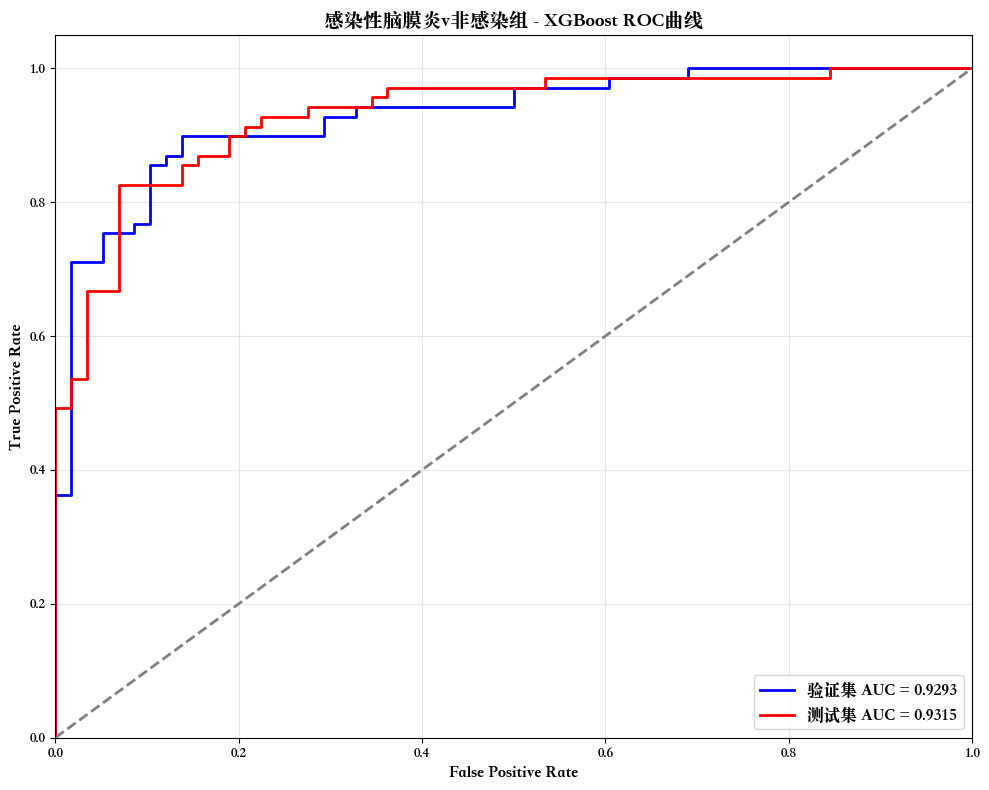

{'XGboost_Dataset8': {'阴性组vs其他': {'val_accuracy': 0.947, 'val_precision': 0.84, 'val_recall': 0.84, 'val_f1': 0.84, 'roc_auc_val': 0.98, 'val_CI': [0.9581, 0.9949], 'test_accuracy': 0.9474, 'test_precision': 0.8696, 'test_recall': 0.8, 'test_f1': 0.8333, 'roc_auc_test': 0.9698, 'test_CI': [0.9411, 0.9915]}, '感染性脑膜炎v非感染组': {'val_accuracy': 0.9213, 'val_precision': 0.9041, 'val_recall': 0.9565, 'val_f1': 0.9296, 'roc_auc_val': 0.9793, 'val_CI': [0.9593, 0.9935], 'test_accuracy': 0.8583, 'test_precision': 0.8592, 'test_recall': 0.8841, 'test_f1': 0.8714, 'roc_auc_test': 0.9135, 'test_CI': [0.8648, 0.9573]}, '细菌性脑膜炎vs其他感染性脑膜炎': {'val_accuracy': 0.9275, 'val_precision': 0.7857, 'val_recall': 0.8462, 'val_f1': 0.8148, 'roc_auc_val': 0.9396, 'val_CI': [0.8462, 0.9959], 'test_accuracy': 0.8841, 'test_precision': 0.7273, 'test_recall': 0.6154, 'test_f1': 0.6667, 'roc_auc_test': 0.8255, 'test_CI': [0.6703, 0.9519]}, '病毒性脑膜炎vs其他感染性脑膜炎': {'val_accuracy': 0.8382, 'val_precision': 0.6786, 'val_recal

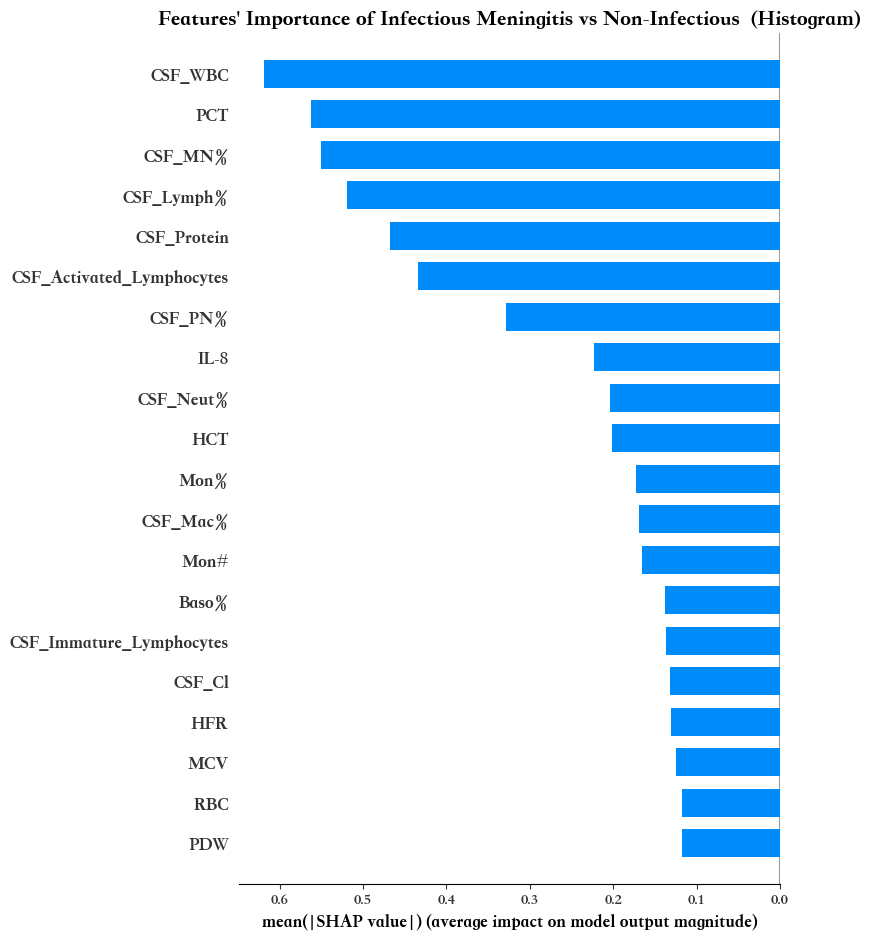


===== SHAP 特征分布 (蜂群图): =====


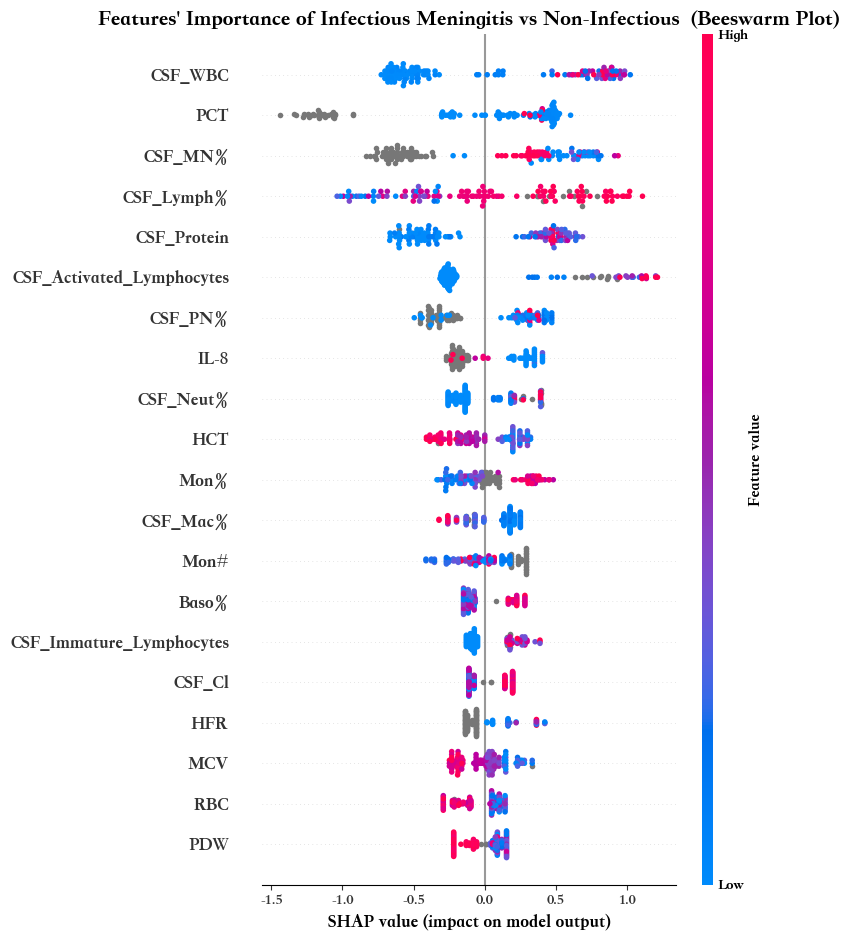

In [ ]:

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎vs非感染性脑膜炎': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df, current_dataset):

    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])
    
    # 得到最优模型
    result = train(X_train, y_train, X_val, y_val, key)
    final_model = result[0]
    # 评估验证集和测试集
    val_results = evaluate_model(final_model, X_val, y_val, "验证", key)
    test_results = evaluate_model(final_model, X_test, y_test, "测试", key)    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)
    feature_names = list(X_train.columns)
    # 绘制shap图
    shap_values = draw_shap(final_model, X_train, X_test, current_dataset, key)
    export_global_shap_importance(shap_values, feature_names, k=20, out_csv=f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/shap/{key}/Dataset{current_dataset}_shap.csv")
    
    return result[2]

    
if extract_integers(data_path)[-1] == 2:
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎vs非感染性脑膜炎': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    result_para = run_model(key, item, filtered_df2, current_dataset)

    # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)

     
        